<a href="https://colab.research.google.com/github/rachitranjan7/Stock-Market-Predictor/blob/main/Stock_Market_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================================================
# CELL 1: Install Required Libraries
# =========================================================

!pip install yfinance tensorflow scikit-learn pandas numpy matplotlib seaborn

In [ ]:
# =========================================================
# CELL 2: Import Libraries
# =========================================================

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam

# Better plot style
sns.set_style("whitegrid")

In [ ]:
# =========================================================
# CELL 3: Download Historical Stock Data
# =========================================================

# You can change this stock symbol
stock_symbol = "AAPL"

# Download around 20 years of data
stock_df = yf.download(
    stock_symbol,
    start="2004-01-01",
    end="2024-01-01"
)

print("First 5 Rows:")
display(stock_df.head())

print(f"\nDataset Shape: {stock_df.shape}")

/tmp/ipykernel_5515/958261751.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_df = yf.download(
[*********************100%***********************]  1 of 1 completed

First 5 Rows:


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2004-01-02,0.318806,0.325848,0.317308,0.322851,144642400
2004-01-05,0.332140,0.335435,0.320904,0.320904,395018400
2004-01-06,0.330941,0.335885,0.325249,0.333338,509348000
2004-01-07,0.338432,0.342028,0.328544,0.331091,586874400
2004-01-08,0.349968,0.355511,0.339331,0.342177,460303200



Dataset Shape: (5033, 5)


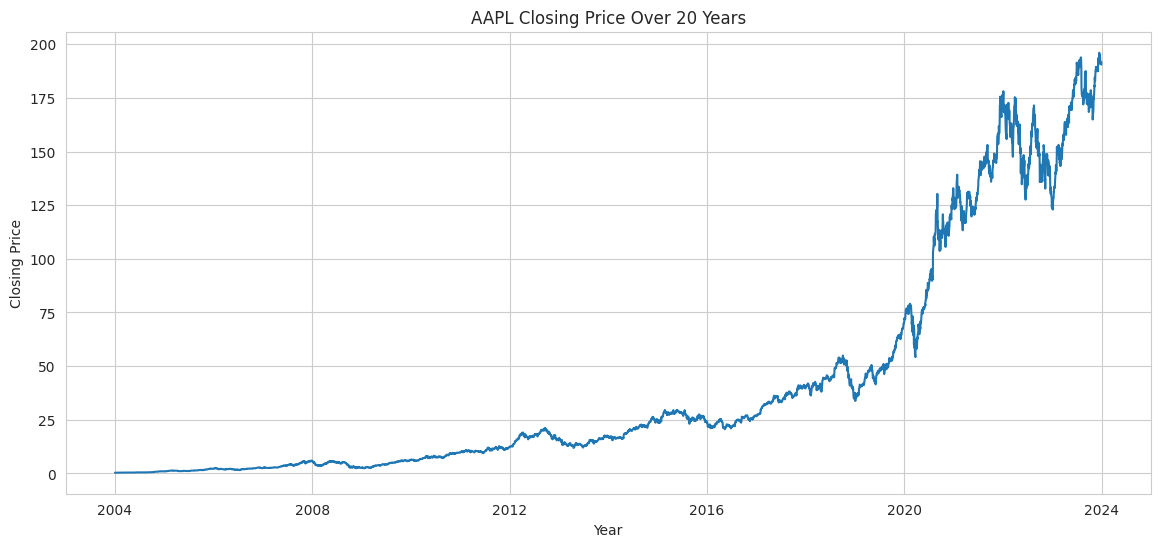

In [ ]:
# =========================================================
# CELL 4: Visualize Closing Price
# =========================================================

plt.figure(figsize=(14,6))

plt.plot(stock_df['Close'])

plt.title(f"{stock_symbol} Closing Price Over 20 Years")
plt.xlabel("Year")
plt.ylabel("Closing Price")

plt.show()

In [ ]:
# =========================================================
# CELL 5: Select Important Features
# =========================================================

# These are the main stock market features
selected_features = [
    'Open',
    'High',
    'Low',
    'Close',
    'Volume'
]

market_data = stock_df[selected_features]

display(market_data.head())

Price,Open,High,Low,Close,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2004-01-02,0.322851,0.325848,0.317308,0.318806,144642400
2004-01-05,0.320904,0.335435,0.320904,0.332140,395018400
2004-01-06,0.333338,0.335885,0.325249,0.330941,509348000
2004-01-07,0.331091,0.342028,0.328544,0.338432,586874400
2004-01-08,0.342177,0.355511,0.339331,0.349968,460303200


In [ ]:
# =========================================================
# CELL 6: Normalize the Data
# =========================================================

# Neural networks train better on scaled data
scaler = MinMaxScaler()

scaled_market_data = scaler.fit_transform(market_data)

print("Scaled Data Shape:", scaled_market_data.shape)

Scaled Data Shape: (5033, 5)


In [ ]:
# =========================================================
# CELL 7: Create Time-Series Sequences
# =========================================================

# Model will look at previous 60 days
sequence_length = 60

X = []
y = []

# Create rolling windows
for i in range(sequence_length, len(scaled_market_data)):

    # Previous 60 days
    X.append(
        scaled_market_data[i-sequence_length:i]
    )

    # Predict next day's closing price
    y.append(
        scaled_market_data[i, 3]
    )

# Convert to numpy arrays
X = np.array(X)
y = np.array(y)

print("Input Shape :", X.shape)
print("Target Shape:", y.shape)

Input Shape : (4973, 60, 5)
Target Shape: (4973,)


In [ ]:
# =========================================================
# CELL 8: Split into Train and Test Sets
# =========================================================

# Keep chronological order (IMPORTANT for time-series)
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("Training Samples:", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])

Training Samples: 3978
Testing Samples : 995


In [ ]:
# =========================================================
# CELL 9: Build CNN Model
# =========================================================

model = Sequential()

# CNN layer learns local price movement patterns
model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu',
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

# Reduce dimensionality
model.add(
    MaxPooling1D(pool_size=2)
)

# Helps reduce overfitting
model.add(
    Dropout(0.2)
)

# Flatten feature maps
model.add(
    Flatten()
)

# Dense layers for final learning
model.add(
    Dense(50, activation='relu')
)

# Final prediction layer
model.add(
    Dense(1)
)

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 58, 64)         │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1856)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │        92,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,925 (366.89 KB)

 Trainable params: 93,925 (366.89 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# =========================================================
# CELL 10: Train the Model
# =========================================================

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 6.5737e-04 - val_loss: 0.0025
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.4265e-04 - val_loss: 0.0020
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.1722e-04 - val_loss: 0.0035
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 8.9539e-05 - val_loss: 0.0026
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 7.3196e-05 - val_loss: 0.0018
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 6.7859e-05 - val_loss: 0.0014
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5.8952e-05 - val_loss: 0.0038
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5.8907e-05 - val_loss: 0.0024
Epoch 9/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5.6454e-05 - val_loss: 0.0027
Epoch 10/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 4.3619e-05 - val_loss: 0.0054
Epoch 11/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5.6519e-05 - val_loss: 0.0043
Epoch 

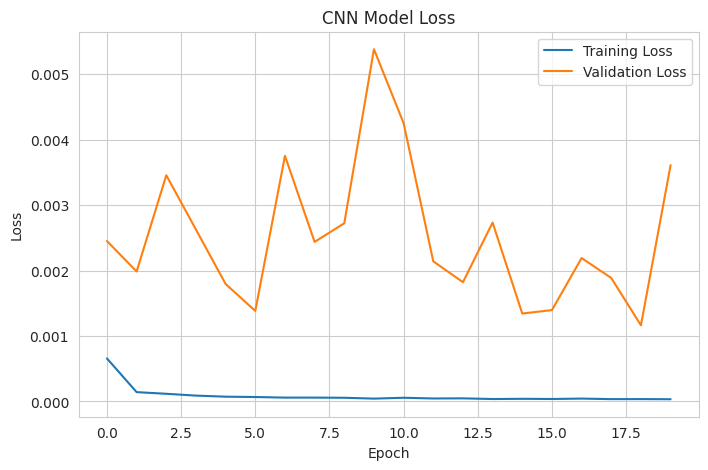

In [ ]:
# =========================================================
# CELL 11: Plot Training Loss
# =========================================================

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("CNN Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

In [ ]:
# =========================================================
# CELL 12: Generate Predictions
# =========================================================

predicted_values = model.predict(X_test)

print("Prediction Shape:", predicted_values.shape)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
Prediction Shape: (995, 1)


In [ ]:
# =========================================================
# CELL 13: Convert Predictions Back to Real Prices
# =========================================================

# Need dummy arrays because scaler expects 5 features
dummy_predicted = np.zeros((len(predicted_values), 5))
dummy_actual = np.zeros((len(y_test), 5))

# Closing price column index = 3
dummy_predicted[:, 3] = predicted_values.flatten()
dummy_actual[:, 3] = y_test

# Convert back to original stock prices
predicted_prices = scaler.inverse_transform(dummy_predicted)[:, 3]
actual_prices = scaler.inverse_transform(dummy_actual)[:, 3]

In [ ]:
# =========================================================
# CELL 14: Evaluate Performance
# =========================================================

rmse = np.sqrt(
    mean_squared_error(actual_prices, predicted_prices)
)

mae = mean_absolute_error(
    actual_prices,
    predicted_prices
)

print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")

RMSE : 11.76
MAE  : 9.82


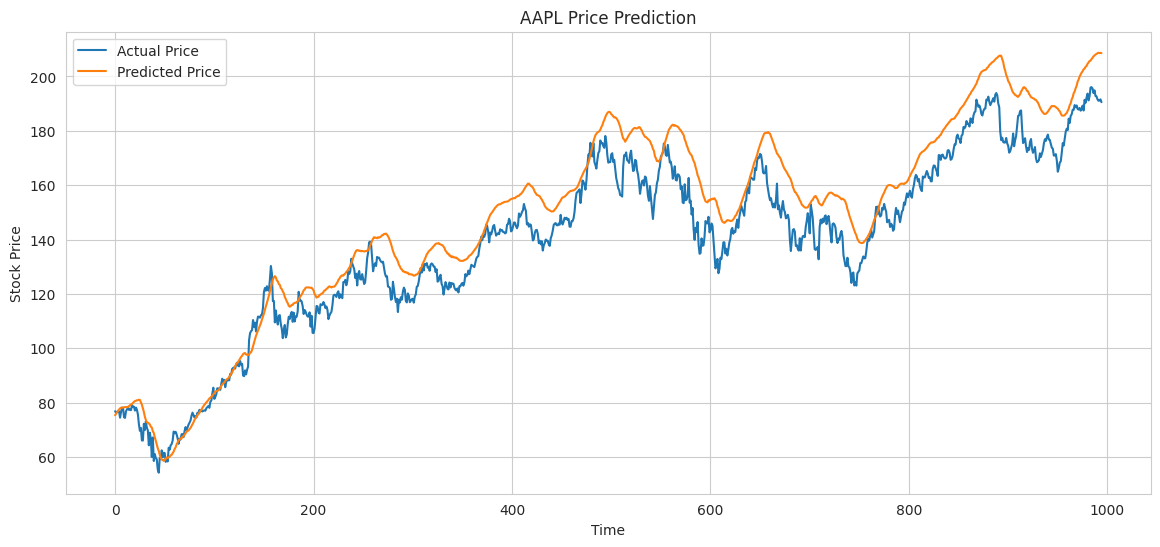

In [ ]:
# =========================================================
# CELL 15: Compare Actual vs Predicted Prices
# =========================================================

plt.figure(figsize=(14,6))

plt.plot(actual_prices, label='Actual Price')
plt.plot(predicted_prices, label='Predicted Price')

plt.title(f"{stock_symbol} Price Prediction")
plt.xlabel("Time")
plt.ylabel("Stock Price")

plt.legend()

plt.show()

In [ ]:
# =========================================================
# CELL 16: Predict Tomorrow's Closing Price
# =========================================================

# Take latest 60-day sequence
latest_sequence = scaled_market_data[-sequence_length:]

# CNN expects batch dimension
latest_sequence = np.expand_dims(latest_sequence, axis=0)

# Predict
next_day_scaled_prediction = model.predict(latest_sequence)

# Convert back to real price
dummy_next_day = np.zeros((1, 5))
dummy_next_day[0, 3] = next_day_scaled_prediction

next_day_price = scaler.inverse_transform(dummy_next_day)[0, 3]

print(f"Predicted Next Day Closing Price: ${next_day_price:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Predicted Next Day Closing Price: $208.57


/tmp/ipykernel_5515/2044273679.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dummy_next_day[0, 3] = next_day_scaled_prediction
